In [54]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline, make_interp_spline
import numpy as np
from pathlib import Path
sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size

import scipy.stats as st
from matplotlib.ticker import LogLocator


# Analyse CFUs from chemostat experiments

In [4]:

repo_folder = Path("../..")

data_folder = repo_folder / "data/4_chemostats/"
figure_folder = repo_folder / 'figures' / '4_chemostats'
figure_folder.mkdir(exist_ok = True)
df_cfu = pd.read_csv(data_folder / "cfus.csv")

In [5]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [6]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [7]:
df_cfu.rename(columns={'reactor':'Carbon source', 'average': 'Mean CFUs/mL', 'stdev': 'Std. CFUs/mL', 'sample_time': 'Time [h]',
                       'species':'Species'}, inplace=True)


In [8]:
df_cfu['Species'] = df_cfu['Species'].str.capitalize()
df_cfu.replace({'Species':{'Ms':'Ml'}}, inplace=True)

In [9]:
df_cfu = pd.concat([df_cfu, df_cfu['count'].str.split('|', expand=True).rename(columns={0:'A', 1:'B', 2:'C'}).apply(lambda x: x.str.strip())], axis=1)

In [10]:
# Calculate CFUs/mL for each replicate
drop_volume = 5*1e-3  # 5 microliters in mL
for i, row in df_cfu.iterrows():
    for rep in 'ABC':
        df_cfu.at[i, f'{rep} CFUs/mL'] = (float(row[rep]) / drop_volume) * np.power(10.0, -row['dilution']) 
# df_cfu['Average 2 CFUs/mL'] = df_cfu[['A CFUs/mL', 'B CFUs/mL', 'C CFUs/mL']].mean(axis=1)

In [11]:
df_cfuL = df_cfu.melt(id_vars=['Carbon source', 'Species', 'Time [h]'], value_vars=['A CFUs/mL', 'B CFUs/mL', 'C CFUs/mL'],
                       var_name='Replicate', value_name='CFUs/mL') 

In [12]:
df_cfuL['Replicate'] = df_cfuL['Replicate'].str.replace(' CFUs/mL', '', regex=False)
df_cfuL['Carbon source'] = df_cfuL['Carbon source'].str.capitalize()

In [13]:
df_cfuL.replace({'Carbon source':{'Glutaric acid':'Glutarate'}}, inplace=True)

# Plot

In [14]:
df_cfuL['Time [h] rounded'] = df_cfuL['Time [h]'].round(1).astype(int)

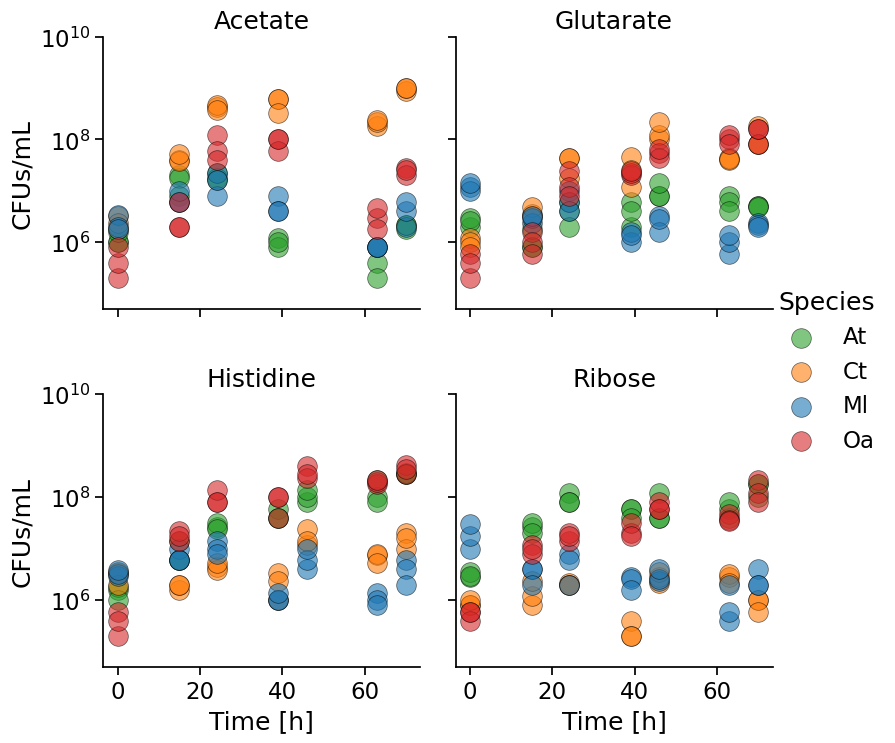

In [16]:
# Alternative: Use FacetGrid with scatter to respect numeric x-axis values
ncols = 2
g = sns.FacetGrid(
    data=df_cfuL,
    col='Carbon source',
    col_wrap=ncols,
    height=4,
    sharey=True,
    sharex=True,
    col_order=['Acetate', 'Glutarate', 'Histidine', 'Ribose'],
    hue='Species',
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    palette=palette
)

# Map scatter plot (respects numeric x-axis)
g.map(plt.scatter, 'Time [h] rounded', 'CFUs/mL', 
      s=200, alpha=0.6, edgecolor='k', linewidth=0.5)

# Set log scale
for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.set_ylim(5e4, 1e10)

# Set titles and labels
g.set_titles("{col_name}")
g.set_axis_labels('Time [h]', 'CFUs/mL')
g.add_legend()

plt.savefig(figure_folder / 'coexistence_chemostat_numeric_x.pdf')
plt.show()

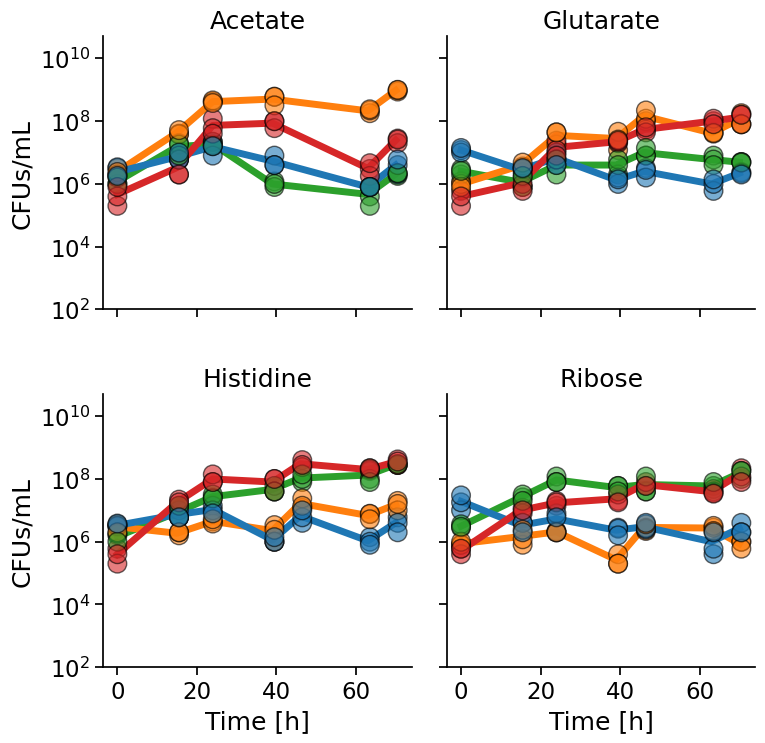

In [18]:
# Alternative 2: Use relplot with scatter - even simpler!
ncols = 2
df_cfuL['Time wiggle'] = df_cfuL['Time [h]'] + np.random.normal(0,1, len(df_cfuL))
g = sns.relplot(
    data=df_cfuL,
    x='Time [h]',  # Treated as numeric
    y='CFUs/mL',
    hue='Species',
    col='Carbon source',
    col_wrap=ncols,
    col_order=['Acetate', 'Glutarate', 'Histidine', 'Ribose'],
    palette=palette,
    hue_order=['At', 'Ct', 'Ml', 'Oa'],
    s=180,
    alpha=0.6,
    height=4,
    facet_kws={'sharey': True, 'sharex': True},
    edgecolor='k',
    linewidth=1,
    legend=False
)
g.map_dataframe(sns.lineplot, x = 'Time [h] rounded', y = 'CFUs/mL', hue = 'Species',  hue_order=['At', 'Ct', 'Ml', 'Oa'], palette = palette, errorbar = None, linewidth = 5, zorder = 0)

# Set log scale
for ax in g.axes.flat:
    ax.set_yscale('log')
    ax.set_ylim(1e2, 5e10)
    # plt.ylim(1e2, 5e10)


# Set titles and labels  
g.set_titles("{col_name}")
g.set_axis_labels('Time [h]', 'CFUs/mL')

plt.savefig(figure_folder / 'coexistence_chemostat_relplot.pdf')
plt.show()

# Compare with assembly experiment 1

In [32]:
assembly_1_folder = Path("../../data/2_first_community_assembly")
df_logmean78 = pd.read_csv(assembly_1_folder / "df_logmean78.csv", index_col=0)

In [34]:
df_cfuL['log10 CFUs/mL'] = np.log10(df_cfuL['CFUs/mL'])

In [35]:
df_cmean = df_cfuL.loc[df_cfuL['Time [h] rounded'] > 41].groupby(['Carbon source', 'Species'])['log10 CFUs/mL'].agg(['mean', 'std']).reset_index()

In [38]:
both_df = pd.merge(left=df_logmean78[['Species', 'Carbon source', 'Mean log10(CFUs/mL)', 'Std log10(CFUs/mL)']], right = df_cmean, on = ['Species', 'Carbon source'], suffixes=('_assembly', '_chemostat'))

In [39]:
both_df.columns = ['Species', 'Carbon source', 'Mean log10 CFUs/mL transfer', 'Std log10 CFUs/mL transfer', 'Mean log10 CFUs/mL chemostat', 'Std log10 CFUs/mL chemostat']

In [40]:
cs_to_style = {'Acetate': 'o', 'Glutarate': 's', 'Histidine': 'D', 'Ribose': '^'}

In [41]:
# both_df['log10 transfer'] = np.log10(both_df['Mean CFUs/mL transfer'])
# both_df['log10 chemostat'] = np.log10(both_df['Mean CFUs/mL chemostat'])

rho, pval = st.pearsonr(both_df['Mean log10 CFUs/mL transfer'], both_df['Mean log10 CFUs/mL chemostat'])

In [42]:
print(rho, pval)

0.6657282089397948 0.00487738377024201


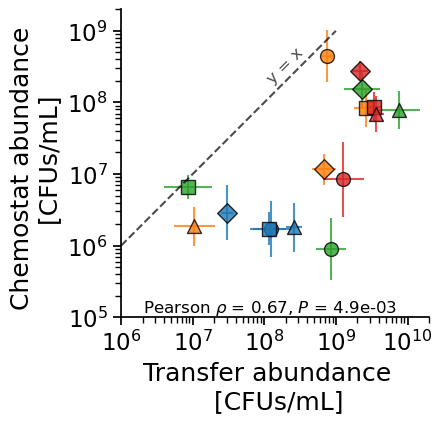

In [58]:
fig, ax = plt.subplots(figsize=(4,4))
major_locator = LogLocator(base=10)
minor_locator = LogLocator(base=10, subs='auto')
# sns.scatterplot(data=both_df, x='Mean CFUs/mL transfer', y='Mean CFUs/mL chemostat', hue='Species', style='Carbon source', palette=palette, s=200, edgecolor='k', linewidth=0.5)
for i, row in both_df.iterrows():
    # Get log10 means and convert back to linear scale for plotting
    x_log = row['Mean log10 CFUs/mL transfer']
    x_std_log = row['Std log10 CFUs/mL transfer']
    y_log = row['Mean log10 CFUs/mL chemostat']
    y_std_log = row['Std log10 CFUs/mL chemostat']
    
    if x_log is None or y_log is None:
        continue
    # Convert to linear scale for plotting
    x = 10**x_log
    y = 10**y_log
    
    # Convert std from log space to linear space (asymmetric error bars)
    x_err_lower = x - 10**(x_log - x_std_log)
    x_err_upper = 10**(x_log + x_std_log) - x
    y_err_lower = y - 10**(y_log - y_std_log)
    y_err_upper = 10**(y_log + y_std_log) - y

    cs = row['Carbon source']
    sp = row['Species']
    j = strains.index(sp)
    ax.scatter(x, y, color = palette[j], marker = cs_to_style[cs],  linewidth=1, s = 100, alpha = 0.8, label = cs, zorder = 2, edgecolor='k')#, zorder = 10)
    ax.errorbar(x, y, 
                xerr=[[x_err_lower], [x_err_upper]], 
                yerr=[[y_err_lower], [y_err_upper]], 
                color = palette[j], alpha = 0.8, markersize = 0, zorder = 1)
ax.plot([1e6, 1e9], [1e6, 1e9], 'k--', alpha = 0.7)
ax.set_xlim(1e6, 2e10)
ax.set_ylim(1e5, 2e9)
plt.xscale('log')
plt.yscale('log')
plt.text(1e8, 1.7e8, 'y = x', fontsize=12, color='k', alpha=0.7, rotation=45, va='bottom', ha='left')
plt.text(2e6, 1e5, fr'Pearson $\rho$ = {rho:.2f}, $P$ = {pval:.1e}', fontsize=12, color='k', va='bottom', ha='left')
plt.xlabel('Transfer abundance  \n [CFUs/mL]')
plt.ylabel('Chemostat abundance \n [CFUs/mL]')
# plt.legend(loc = 'upper left', bbox_to_anchor=(1, 1))
ax.set_aspect('equal', adjustable='box')
ax.xaxis.set_major_locator(major_locator)
ax.xaxis.set_minor_locator(minor_locator)
ax.yaxis.set_major_locator(major_locator)
ax.yaxis.set_minor_locator(minor_locator)
sns.despine()
plt.savefig(figure_folder / 'assembly_chemostat_comparison.pdf', bbox_inches='tight')
# sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))

In [26]:
# Compute the rank for both conditions
both_df['Rank transfer'] = both_df.groupby(['Carbon source'])['Mean CFUs/mL transfer'].rank(ascending=False)
both_df['Rank chemostat'] = both_df.groupby(['Carbon source'])['Mean CFUs/mL chemostat'].rank(ascending=False)

In [27]:
both_df.sort_values(by=['Carbon source'])

,Species,Carbon source,Mean CFUs/mL transfer,Std CFUs/mL transfer,Mean CFUs/mL chemostat,Std CFUs/mL chemostat,log10 transfer,log10 chemostat,Rank transfer,Rank chemostat
0,At,Acetate,9.333333e+08,3.932768e+08,1.266667e+06,9.092121e+05,8.970037,6.102662,2.0,4.0
4,Ct,Acetate,7.666667e+08,1.542293e+08,5.833333e+08,4.078071e+08,8.884607,8.765917,3.0,1.0
8,Ml,Acetate,1.513333e+08,1.099939e+08,2.400000e+06,2.161481e+06,8.179935,6.380211,4.0,3.0
12,Oa,Acetate,1.470000e+09,7.498000e+08,1.390000e+07,1.211726e+07,9.167317,7.143015,1.0,2.0
1,At,Glutarate,1.100000e+07,9.186947e+06,6.977778e+06,3.058504e+06,7.041393,6.843717,4.0,3.0
5,Ct,Glutarate,2.800000e+09,1.102724e+09,1.006667e+08,6.334035e+07,9.447158,8.002886,2.0,1.0
9,Ml,Glutarate,1.300000e+08,5.899152e+07,1.911111e+06,8.432740e+05,8.113943,6.281286,3.0,4.0
13,Oa,Glutarate,3.500000e+09,8.461678e+08,9.577778e+07,4.299354e+07,9.544068,7.981265,1.0,2.0
2,At,Histidine,2.600000e+09,1.166190e+09,1.755556e+08,9.368980e+07,9.414973,8.244415,1.0,2.0
6,Ct,Histidine,7.333333e+08,3.435501e+08,1.295556e+07,6.194980e+06,8.865301,7.112456,3.0,3.0


In [28]:
st.spearmanr(both_df['log10 transfer'], both_df['log10 chemostat'])

SignificanceResult(statistic=np.float64(0.6205882352941177), pvalue=np.float64(0.010313515549677674))

# Rate lag trade off

In [29]:

gp_folder = repo_folder / 'data/1_growth_phenotyping'

rate_df = pd.read_csv(gp_folder / 'fitted_growth_parameters.csv', index_col=0)
rate_df['Carbon source'] = rate_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
rate_df['# CS'] = 1
rate_df.loc[rate_df['Carbon source'] == 'No cs', '# CS'] = 0
rate_df.replace({'max_growth_rate':{np.nan:0}}, inplace=True)



In [30]:
species_list = ['At', 'Ct', 'Ml', 'Oa']

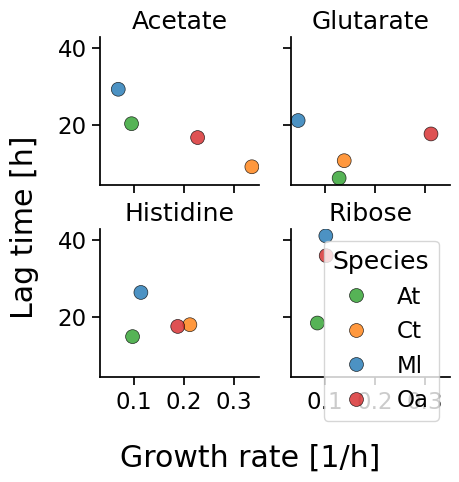

In [31]:
four_cs = ['Acetate', 'Glutarate', 'Histidine', 'Ribose']
fig, axes = plt.subplots(2,2, figsize = (5,5), sharex=True, sharey = True)
axes = axes.flatten()
for i, cs in enumerate(four_cs):
    ax = axes[i]
    idxcs = rate_df['Carbon source'] == cs
    if i == 3:
        legend=True
    else:
        legend = False
    ax.set_title(cs)
    sns.scatterplot(rate_df.loc[idxcs], x = 'max_growth_rate', y = 'lag', ax = ax, hue = 'Species',
                    s = 100,
                    alpha = 0.8,
                    edgecolor='k',
                    linewidth=0.5,
                    palette = palette, hue_order = species_list, legend = legend)
    ax.set_xlabel('')
    ax.set_ylabel('')

fig.supxlabel('Growth rate [1/h]')
fig.supylabel('Lag time [h]')
plt.subplots_adjust(left = 0.2, bottom=0.2, hspace = 0.3, wspace=0.2)
sns.despine()
# plt.savefig()